# Graphs

A **graph** $G = (V, E)$ is a set of **vertices** (or nodes) $V$ together with a set of **edges** $E$, where each edge joins a pair of vertices. Graphs model anything made of things and connections between them: road maps, social networks, the internet, course prerequisites, molecules.

We will build and visualize graphs with `networkx`, and implement the core traversal algorithms (BFS and DFS) ourselves.

## Terminology

- **Undirected** graph: edges have no direction ($\{u, v\}$). **Directed** graph (digraph): edges are ordered pairs $(u, v)$.
- **Weighted** graph: each edge carries a number (a cost, distance, capacity, …).
- **Simple** graph: no self-loops and at most one edge between any two vertices. A **multigraph** allows multiple edges.
- Two vertices joined by an edge are **adjacent** (neighbors). An edge is **incident** to each of its endpoints.

Here is a small undirected graph we will reuse.

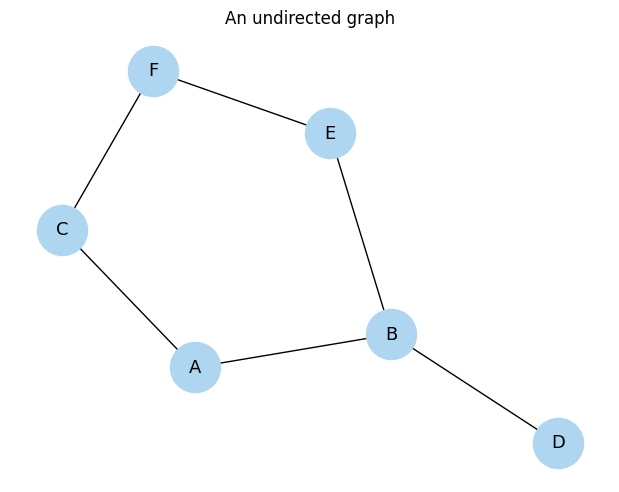

|V| = 6 vertices, |E| = 6 edges


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Adjacency-list description: each vertex maps to its list of neighbors.
graph = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "F"],
    "F": ["C", "E"],
}

G = nx.Graph(graph)
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6, 4.5))
nx.draw(G, pos, with_labels=True, node_color="#aed6f1", node_size=1300, font_size=13)
plt.title("An undirected graph")
plt.show()

print(f"|V| = {G.number_of_nodes()} vertices, |E| = {G.number_of_edges()} edges")

## Two Ways to Store a Graph

- **Adjacency list:** for each vertex, the list of its neighbors (the dictionary `graph` above). Compact for **sparse** graphs (few edges).
- **Adjacency matrix:** an $n \times n$ matrix $M$ with $M_{ij} = 1$ when vertices $i$ and $j$ are adjacent. Simple and fast to query, but uses $n^2$ space even when there are few edges. (Compare with the zero-one matrices of relations in notebook 08.)

In [2]:
import numpy as np

nodes = sorted(G.nodes())
M = nx.to_numpy_array(G, nodelist=nodes, dtype=int)

print("Vertices:", nodes)
print("\nAdjacency matrix:\n", M)
print("\nThe matrix is symmetric for an undirected graph:", np.array_equal(M, M.T))

Vertices: ['A', 'B', 'C', 'D', 'E', 'F']

Adjacency matrix:
 [[0 1 1 0 0 0]
 [1 0 0 1 1 0]
 [1 0 0 0 0 1]
 [0 1 0 0 0 0]
 [0 1 0 0 0 1]
 [0 0 1 0 1 0]]

The matrix is symmetric for an undirected graph: True


## Degree and the Handshaking Theorem

The **degree** of a vertex is the number of edges incident to it. There is a beautiful counting fact:

$$\sum_{v \in V} \deg(v) = 2\,|E|.$$

This is the **Handshaking Theorem**: every edge contributes exactly $2$ to the total degree (one for each endpoint). A consequence is that **the number of vertices with odd degree is always even**.

In [3]:
degrees = dict(G.degree())
print("degrees:", degrees)

total_degree = sum(degrees.values())
print("\nsum of degrees:", total_degree)
print("2 * |E|       :", 2 * G.number_of_edges())
print("handshaking theorem holds:", total_degree == 2 * G.number_of_edges())

odd = [v for v, d in degrees.items() if d % 2 == 1]
print("\nvertices of odd degree:", odd, "-> count is even:", len(odd) % 2 == 0)

degrees: {'A': 2, 'B': 3, 'C': 2, 'D': 1, 'E': 2, 'F': 2}

sum of degrees: 12
2 * |E|       : 12
handshaking theorem holds: True

vertices of odd degree: ['B', 'D'] -> count is even: True


## Paths, Cycles, and Connectivity

A **path** is a sequence of vertices each adjacent to the next. A **cycle** is a path that starts and ends at the same vertex without repeating an edge. A graph is **connected** if there is a path between every pair of vertices.

In [4]:
print("Is the graph connected?", nx.is_connected(G))
print("A path from A to D:", nx.shortest_path(G, "A", "D"))
print("Does the graph contain a cycle?", len(nx.cycle_basis(G)) > 0)
print("One cycle:", nx.cycle_basis(G)[0] if nx.cycle_basis(G) else None)

Is the graph connected? True
A path from A to D: ['A', 'B', 'D']
Does the graph contain a cycle? True
One cycle: ['C', 'A', 'B', 'E', 'F']


## Graph Traversal: BFS and DFS

To explore a graph we visit vertices systematically:

- **Breadth-First Search (BFS)** explores level by level, using a **queue**. It finds shortest paths (in number of edges) from the start vertex.
- **Depth-First Search (DFS)** dives as deep as possible before backtracking, using a **stack** (or recursion).

Both run in $O(|V| + |E|)$ time. Here are from-scratch implementations on the adjacency-list dictionary.

In [5]:
from collections import deque


def bfs(graph, start):
    visited, seen, queue = [], {start}, deque([start])
    while queue:
        node = queue.popleft()
        visited.append(node)
        for neighbor in graph[node]:
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append(neighbor)
    return visited


def dfs(graph, start, seen=None, order=None):
    if seen is None:
        seen, order = set(), []
    seen.add(start)
    order.append(start)
    for neighbor in graph[start]:
        if neighbor not in seen:
            dfs(graph, neighbor, seen, order)
    return order


print("BFS from A:", bfs(graph, "A"))
print("DFS from A:", dfs(graph, "A"))

BFS from A: ['A', 'B', 'C', 'D', 'E', 'F']
DFS from A: ['A', 'B', 'D', 'E', 'F', 'C']


## Weighted Graphs and Shortest Paths

When edges have weights, the "shortest" path is the one of least **total weight**, not fewest edges. **Dijkstra's algorithm** finds shortest paths from a source to all other vertices in a graph with non-negative weights.

Shortest A -> E path: ['A', 'C', 'F', 'E']
Total weight: 20


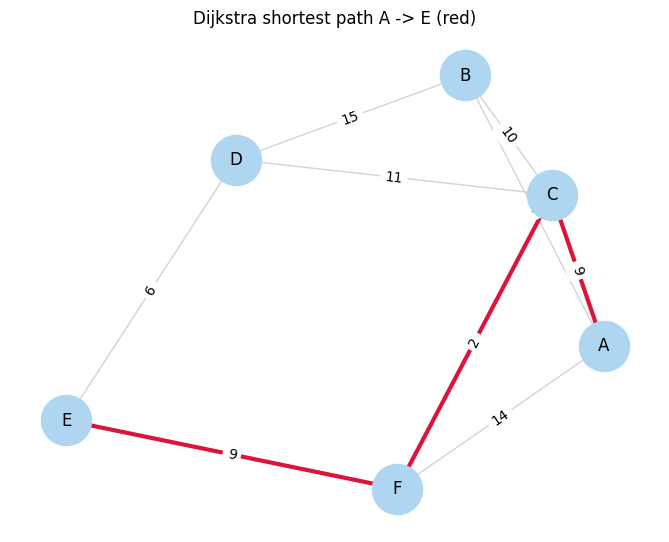

In [6]:
W = nx.Graph()
W.add_weighted_edges_from([
    ("A", "B", 7), ("A", "C", 9), ("A", "F", 14), ("B", "C", 10),
    ("B", "D", 15), ("C", "D", 11), ("C", "F", 2), ("D", "E", 6), ("F", "E", 9),
])

path = nx.dijkstra_path(W, "A", "E")
length = nx.dijkstra_path_length(W, "A", "E")
print("Shortest A -> E path:", path)
print("Total weight:", length)

pos = nx.spring_layout(W, seed=3)
on_path = list(zip(path, path[1:]))
edge_colors = ["crimson" if (u, v) in on_path or (v, u) in on_path else "lightgray" for u, v in W.edges()]
widths = [3 if (u, v) in on_path or (v, u) in on_path else 1 for u, v in W.edges()]
plt.figure(figsize=(6.5, 5))
nx.draw(W, pos, with_labels=True, node_color="#aed6f1", node_size=1300,
        edge_color=edge_colors, width=widths, font_size=12)
nx.draw_networkx_edge_labels(W, pos, edge_labels=nx.get_edge_attributes(W, "weight"))
plt.title("Dijkstra shortest path A -> E (red)")
plt.show()

## Some Special Graphs

A few families come up so often they have names:

- **Complete graph $K_n$:** every pair of the $n$ vertices is joined by an edge.
- **Cycle graph $C_n$:** $n$ vertices connected in a single ring.
- **Complete bipartite graph $K_{m,n}$:** vertices split into two groups of sizes $m$ and $n$, with every vertex in one group joined to every vertex in the other (and none within a group).

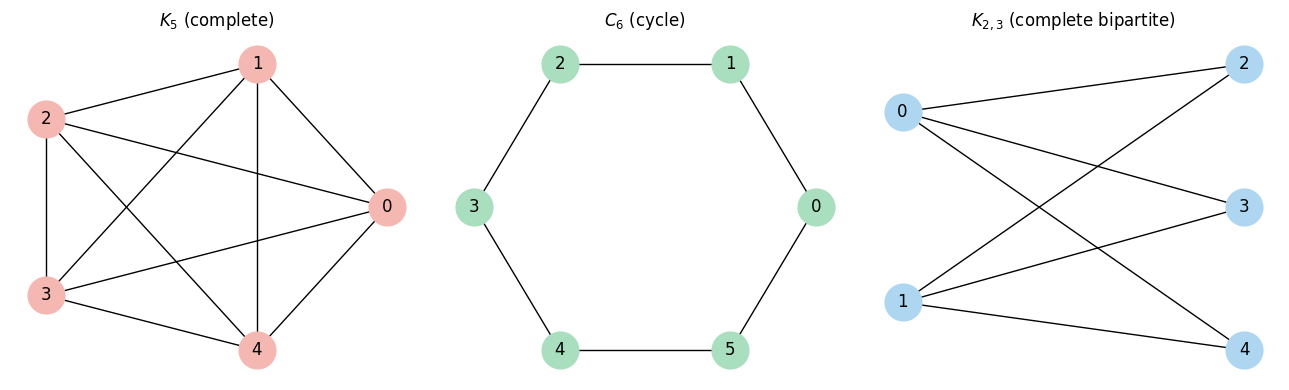

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

K5 = nx.complete_graph(5)
nx.draw(K5, nx.circular_layout(K5), ax=axes[0], with_labels=True, node_color="#f5b7b1", node_size=700)
axes[0].set_title("$K_5$ (complete)")

C6 = nx.cycle_graph(6)
nx.draw(C6, nx.circular_layout(C6), ax=axes[1], with_labels=True, node_color="#a9dfbf", node_size=700)
axes[1].set_title("$C_6$ (cycle)")

K23 = nx.complete_bipartite_graph(2, 3)
pos = {0: (0, 1), 1: (0, -1), 2: (2, 1.5), 3: (2, 0), 4: (2, -1.5)}
nx.draw(K23, pos, ax=axes[2], with_labels=True, node_color="#aed6f1", node_size=700)
axes[2].set_title("$K_{2,3}$ (complete bipartite)")

plt.tight_layout()
plt.show()

### Euler and Hamilton

Two famous questions about "traversing everything once":

- An **Euler circuit** uses every **edge** exactly once and returns to the start. A connected graph has one **iff every vertex has even degree**.
- A **Hamilton cycle** visits every **vertex** exactly once and returns to the start. Surprisingly, no simple efficient test is known — deciding this is **NP-complete**.

## Worked Examples

A few examples solved with Python. (The exercises in the next section are for you to solve — their solutions live in the matching notebook in `solutions/`.)

### Example 1: Degree Sequence

The degree sequence lists the degrees of all vertices (often in decreasing order). Compute it for a small graph.

In [8]:
import networkx as nx

G = nx.Graph({"A": ["B", "C"], "B": ["A", "C"], "C": ["A", "B", "D"], "D": ["C"]})
print("degree of each vertex:", dict(G.degree()))
print("degree sequence:", sorted((d for _, d in G.degree()), reverse=True))

degree of each vertex: {'A': 2, 'B': 2, 'C': 3, 'D': 1}
degree sequence: [3, 2, 2, 1]


### Example 2: Connected Components

A graph may split into several connected pieces. Count the components of a graph that has two separate parts.

In [9]:
import networkx as nx

H = nx.Graph()
H.add_edges_from([("A", "B"), ("B", "C"), ("X", "Y")])
print("number of components:", nx.number_connected_components(H))
print("components:", [sorted(c) for c in nx.connected_components(H)])

number of components: 2
components: [['A', 'B', 'C'], ['X', 'Y']]


## Graphs Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/12_graphs_key.ipynb`](solutions/12_graphs_key.ipynb).

### Problem 1: Handshaking Theorem

Build the graph in the starter and verify the Handshaking Theorem: the sum of all vertex degrees equals twice the number of edges.

In [10]:
import networkx as nx
G = nx.Graph({"A": ["B", "C"], "B": ["A", "C", "D"], "C": ["A", "B"], "D": ["B"]})
# WRITE YOUR CODE BELOW


### Problem 2: Breadth-First Search

Implement breadth-first search on the adjacency-list `graph` in the starter and print the order in which vertices are visited starting from `A`.

In [11]:
from collections import deque
graph = {"A": ["B", "C"], "B": ["A", "D"], "C": ["A", "D"], "D": ["B", "C"]}
# WRITE YOUR CODE BELOW


### Problem 3: Shortest Path

Using `networkx`, find the shortest (least-weight) path from `A` to `D` in the weighted graph in the starter, and its total distance.

In [12]:
import networkx as nx
W = nx.Graph()
W.add_weighted_edges_from([("A", "B", 1), ("B", "C", 2), ("A", "C", 4), ("C", "D", 1)])
# WRITE YOUR CODE BELOW


### Problem 4: Euler Circuits

A connected graph has an Euler circuit iff every vertex has even degree. Use `networkx.is_eulerian` to check the complete graph $K_5$ and the complete bipartite graph $K_{2,3}$.

In [13]:
import networkx as nx
# WRITE YOUR CODE BELOW
